In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import os
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

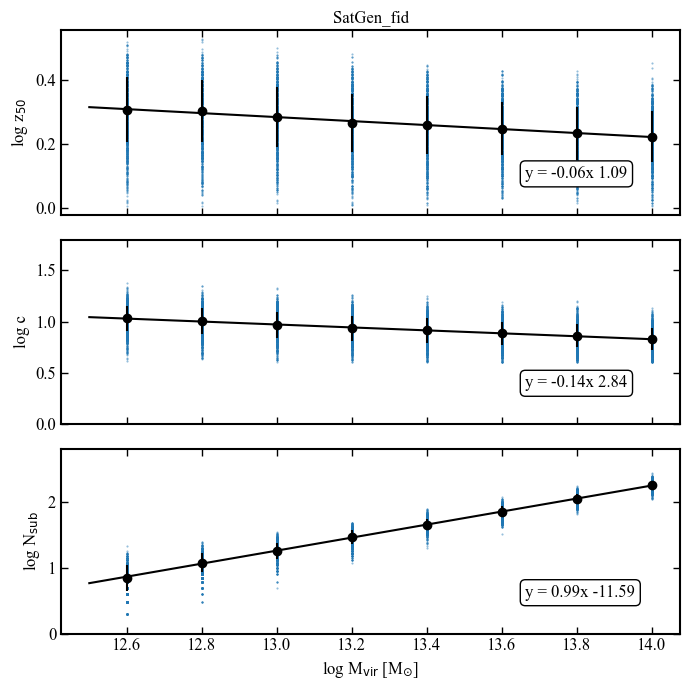

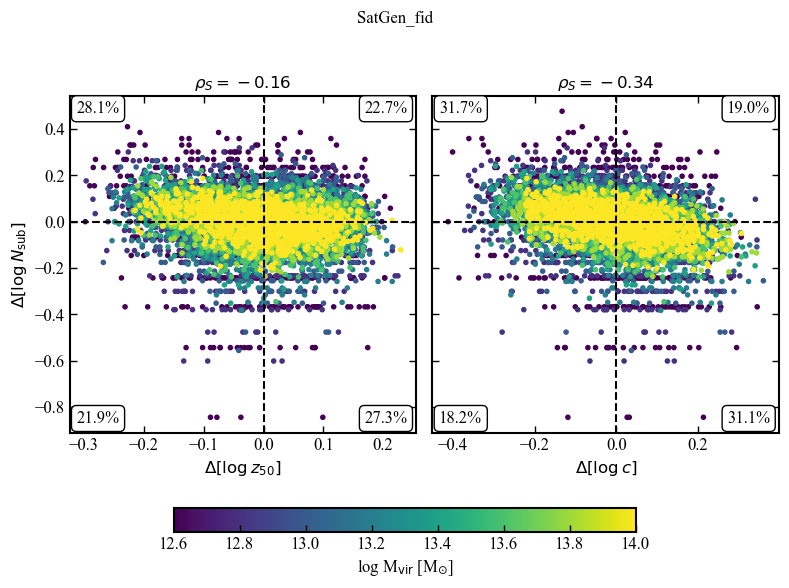

In [4]:
fid = jsm_ancillary.load_massspec("../../data/fid/", "artificial", 0)

satgen_high_mass = fid[fid["logMvir"] > 12.5]
satgen_high_mass = satgen_high_mass.sort_values("logMvir")

norm = jsm_stats.CorrNorm_satgen(satgen_high_mass, dataset_title="SatGen_fid")
# norm.write_summary_tab(filepath= "../../data/summary_tabs/")

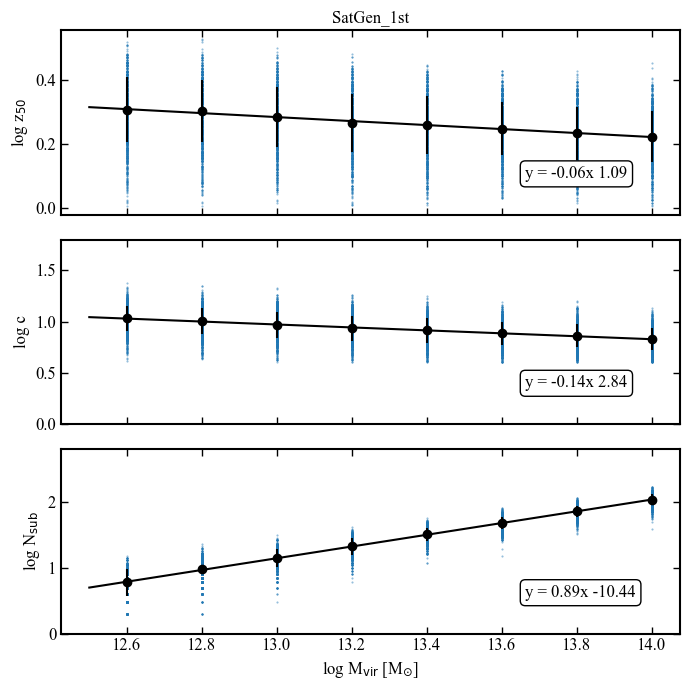

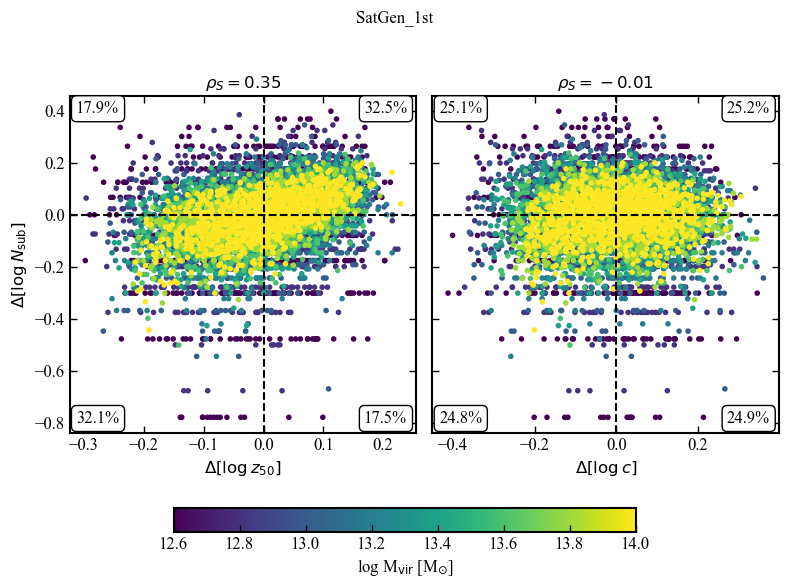

In [5]:
first_order = jsm_ancillary.load_massspec("../../data/fid/", "artificial", 1)

satgen_high_mass = first_order[first_order["logMvir"] > 12.5]
satgen_high_mass = satgen_high_mass.sort_values("logMvir")

norm1st = jsm_stats.CorrNorm_satgen(satgen_high_mass, dataset_title="SatGen_1st")
# norm.write_summary_tab(filepath= "../../data/summary_tabs/")

In [6]:
full_data = jsm_ancillary.load_massspec_withorders("../../data/fid/", "artificial")

In [7]:
subset = full_data[(full_data["logMvir"] >= 13.1) & (full_data["logMvir"] < 13.3)][["logz50", "logc", "logfsub", "logNsub"]]

subset_1st = full_data[(full_data["logMvir"] >= 13.1) & (full_data["logMvir"] < 13.3)][["logz50", "logc", "logfsub", "logNsub_1st"]]

subset_2nd = full_data[(full_data["logMvir"] >= 13.1) & (full_data["logMvir"] < 13.3)][["logz50", "logc", "logfsub", "logNsub_2nd"]]

subset_3rd = full_data[(full_data["logMvir"] >= 13.1) & (full_data["logMvir"] < 13.3)][["logz50", "logc", "logfsub", "logNsub_3rd"]]

In [8]:
subset_2nd.replace([np.inf, -np.inf], 0.0001, inplace=True)
subset_3rd.replace([np.inf, -np.inf], 0.0001, inplace=True)

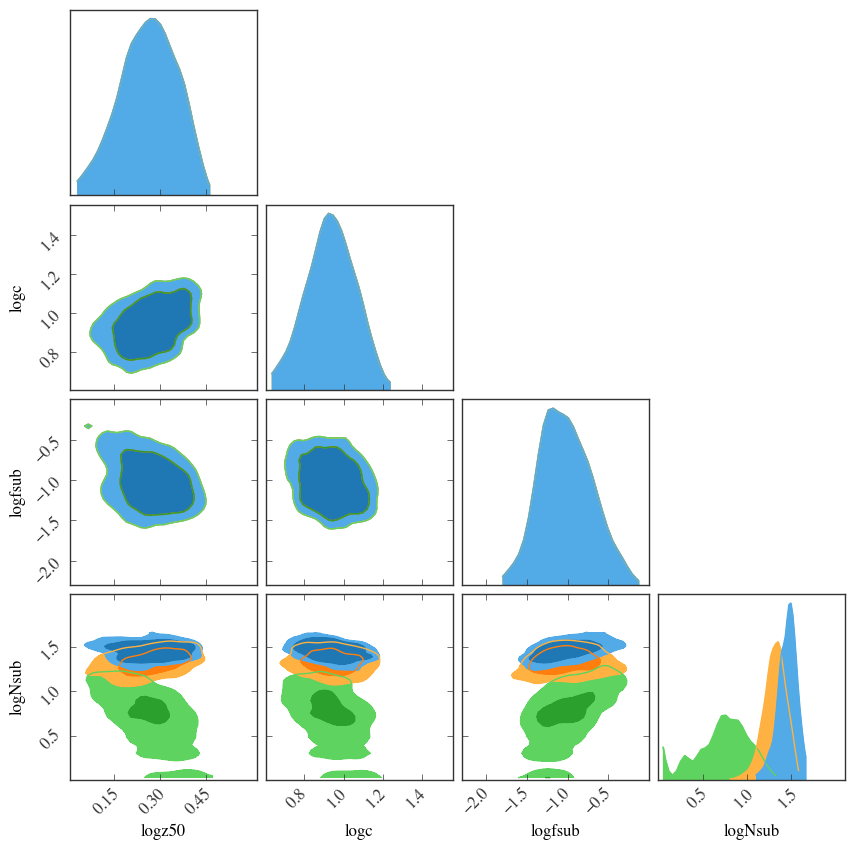

In [9]:
paramRanges = [[full_data["logz50"].min(), full_data["logz50"].max()],
                [full_data["logc"].min(), full_data["logc"].max()],
                [-2.3, 0.0],
                [0.0, 2.1]]


        # corner plot
corner_comp = pygtc.plotGTC(
    chains=[subset, subset_1st, subset_2nd],
    smoothingKernel=1.4,
    figureSize=10,
    paramRanges=paramRanges,
    customTickFont={'family':'Times', 'size':12},
    customLegendFont={'family':'Times', 'size':12},
    customLabelFont={'family':'Times', 'size':12},
    mathTextFontSet=None,
    panelSpacing='loose')

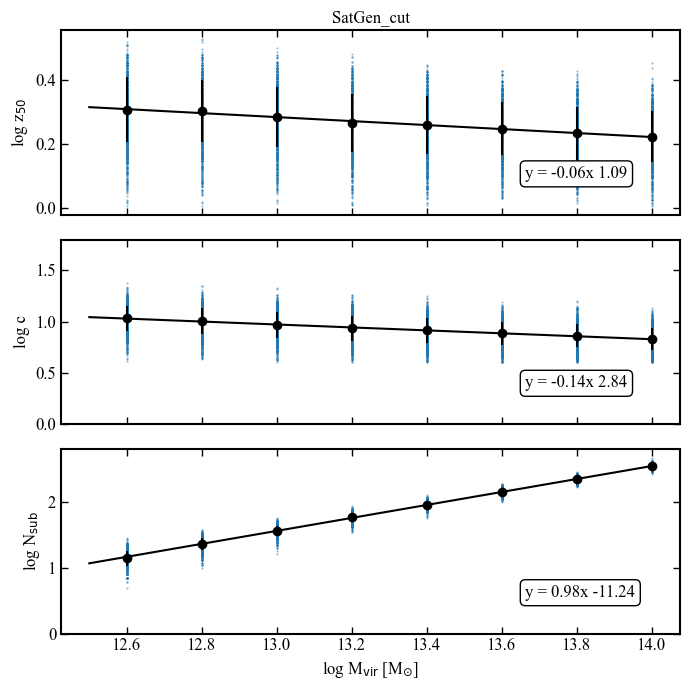

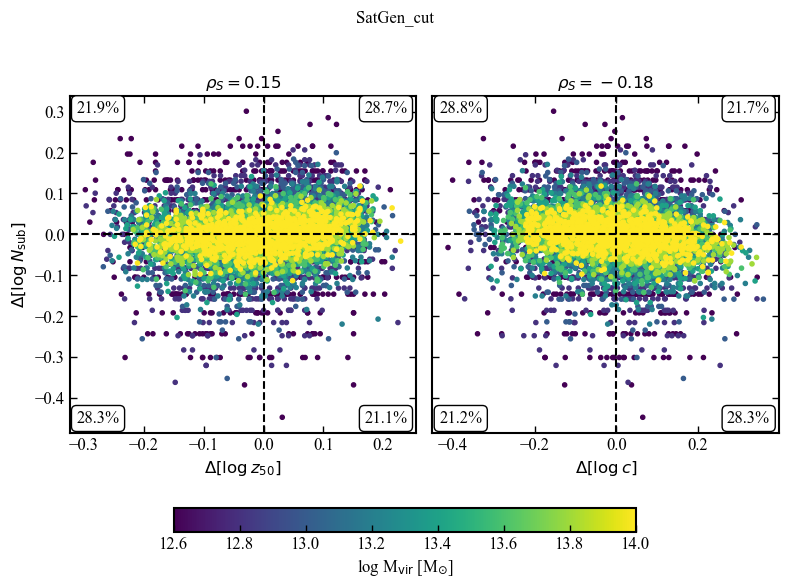

In [10]:
cut = jsm_ancillary.load_massspec("../../data/fid/", "withering", 0)
cut_high = cut[cut["logMvir"] > 12.5]
cut_high = cut_high.sort_values("logMvir")
cut_norm = jsm_stats.CorrNorm_satgen(cut_high, dataset_title="SatGen_cut")
cut_norm.write_summary_tab(filepath= "../../data/summary_tabs/")

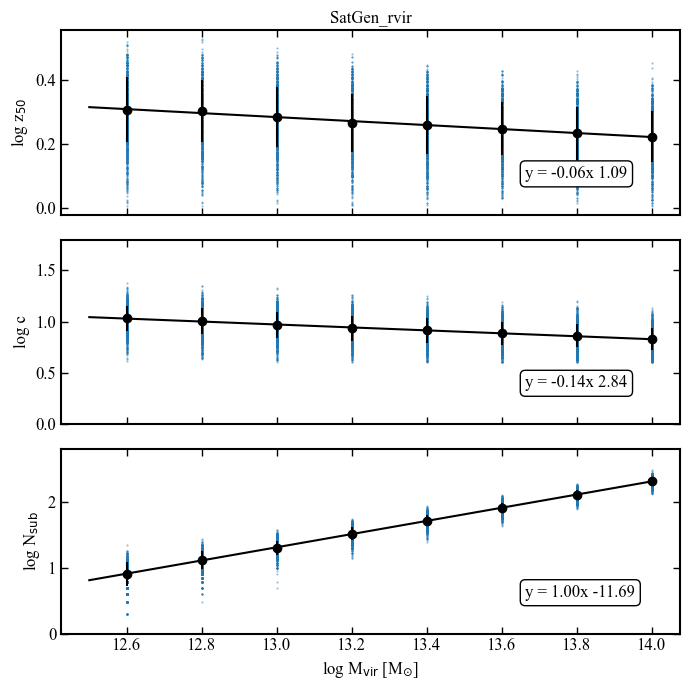

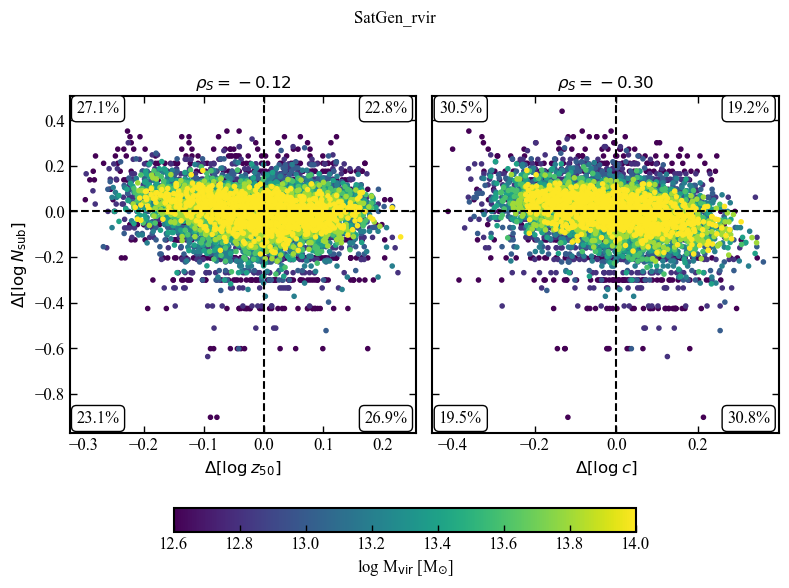

In [11]:
rvir = jsm_ancillary.load_massspec("../../data/fid/", "Rvir", 0)
rvir_high = rvir[rvir["logMvir"] > 12.5]
rvir_high = rvir_high.sort_values("logMvir")
rvir_norm = jsm_stats.CorrNorm_satgen(rvir_high, dataset_title="SatGen_rvir")
rvir_norm.write_summary_tab(filepath= "../../data/summary_tabs/")

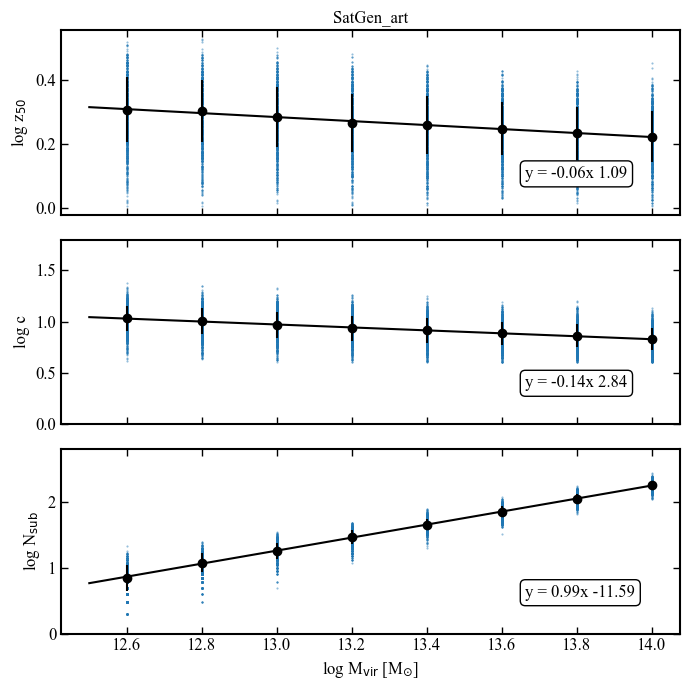

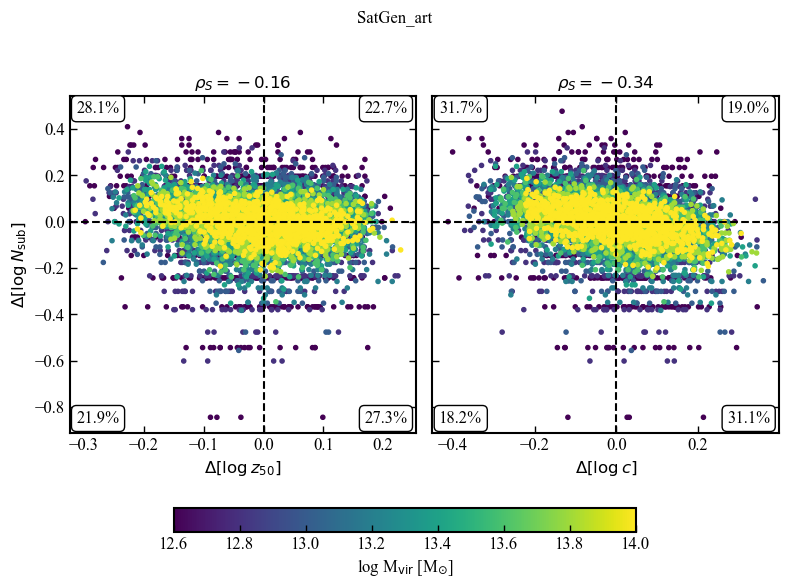

In [12]:
art = jsm_ancillary.load_massspec("../../data/fid/", "artificial", 0)
art_high = art[art["logMvir"] > 12.5]
art_high = art_high.sort_values("logMvir")
art_norm = jsm_stats.CorrNorm_satgen(art_high, dataset_title="SatGen_art")

In [14]:
satgen_high_mass = full_data[full_data["logMvir"] > 12.5]

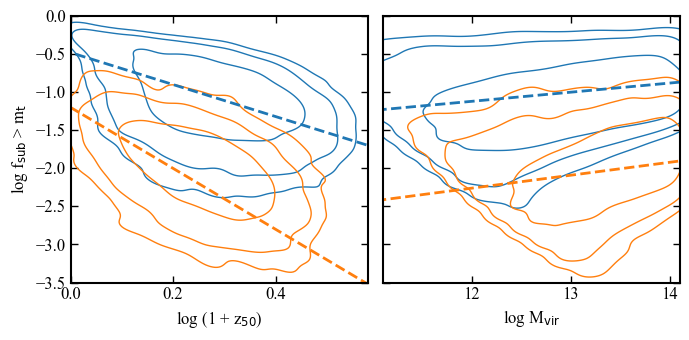

In [56]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(double_textwidth, single_textwidth))

z50_smooth = np.linspace(-0.1, 0.6)
halo_smooth = np.linspace(10, 15)

def z50_relation(z50, a, b):
    return a + b*z50

def Mvir_relation(Mvir, a, b):
    return a + b*np.log10(10**Mvir/1e12)

sns.kdeplot(x=full_data["logz50"], y=full_data["logfsub_1st"], levels=levelz, linewidths=1, ax=ax[0])
sns.kdeplot(x=full_data["logz50"], y=full_data["logfsub_2nd"], levels=levelz, linewidths=1, ax=ax[0])

sns.kdeplot(x=full_data["logMvir"], y=full_data["logfsub_1st"], levels=levelz, linewidths=1, ax=ax[1])
sns.kdeplot(x=full_data["logMvir"], y=full_data["logfsub_2nd"], levels=levelz, linewidths=1, ax=ax[1])

plt.tight_layout()
ax[0].set_ylabel("log f$_{\\rm sub}$ > m$_{\\rm t}$")
ax[0].set_xlabel("log (1 + z$_{\\rm 50}$)")
ax[1].set_xlabel("log M$_{\\rm vir}$")


ax[0].plot(z50_smooth, z50_relation(z50_smooth, -0.48, -2.1), c="C0", ls="--", lw=2)
ax[0].plot(z50_smooth, z50_relation(z50_smooth, -1.2, -4), c="C1", ls="--", lw=2)

ax[1].plot(halo_smooth, Mvir_relation(halo_smooth, -1.12, 0.12), c="C0", ls="--", lw=2)
ax[1].plot(halo_smooth, Mvir_relation(halo_smooth, -2.26, 0.17), c="C1", ls="--", lw=2)

ax[0].set_xlim(0, 0.58)
ax[1].set_xlim(11.1, 14.1)
ax[0].set_ylim(-3.5, 0)

# fig.title("SatGen")
plt.tight_layout()
plt.show()